# Trajectory Inference with Monocle 2

This notebook demonstrates a Monocle 2-style trajectory workflow on the public processed Olsson hematopoiesis matrices from GEO. The workflow covers DDRTree reconstruction, branch-level pseudotime visualization, dynamic gene trends, dynamic heatmaps, and BEAM analysis for the same hematopoietic trajectory.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov
from omicverse.single import Monocle

ov.plot_set(font_path='Arial')
np.random.seed(42)

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Method background

Monocle frames trajectory inference as an ordering problem: first identify genes that capture biological progression, then project cells into a low-dimensional space, and finally learn a branched principal graph that assigns each cell both **pseudotime** and a discrete **State**. In Monocle 2, this geometry is learned with reversed graph embedding (RGE), usually exposed through `DDRTree`.

References:
- [Monocle 2 documentation](https://cole-trapnell-lab.github.io/monocle-release/docs/)
- [Monocle tutorial collection](https://cole-trapnell-lab.github.io/monocle-release/tutorials/)
- [Monocle 2 RGE paper](https://cole-trapnell-lab.github.io/pdfs/papers/qiu-monocle2.pdf)

The Olsson tutorial is a classic example because it shows how Monocle 2 recovers differentiation trunks and fate branches in a hematopoietic system with real branch points.

## Data source

This tutorial uses the public processed single-cell matrices from GEO `GSE70245`. The supplementary matrices are provided as RSEM expression values reported as `log2(TPM + 1)`, and the accompanying metadata are used to annotate sample groups and cell subtypes.

## Download the official GEO processed matrices

In [2]:
DATA_DIR = Path('data/olsson_geo')
RAW_DIR = DATA_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

GEO_FILES = [
    {
        'acc': 'GSE70236',
        'filename': 'GSE70236_Cmp.txt.gz',
        'subtype': 'Cmp',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70236/suppl/GSE70236_Cmp.txt.gz',
    },
    {
        'acc': 'GSE70238',
        'filename': 'GSE70238_GG1.txt.gz',
        'subtype': 'GG1',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70238/suppl/GSE70238_GG1.txt.gz',
    },
    {
        'acc': 'GSE70239',
        'filename': 'GSE70239_Gfi1.Null.txt.gz',
        'subtype': 'Gfi1_knockout',
        'genotype': 'KO',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70239/suppl/GSE70239_Gfi1.Null.txt.gz',
    },
    {
        'acc': 'GSE70240',
        'filename': 'GSE70240_Gmp.txt.gz',
        'subtype': 'Gmp',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70240/suppl/GSE70240_Gmp.txt.gz',
    },
    {
        'acc': 'GSE70241',
        'filename': 'GSE70241_IG2.txt.gz',
        'subtype': 'IG2',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70241/suppl/GSE70241_IG2.txt.gz',
    },
    {
        'acc': 'GSE70242',
        'filename': 'GSE70242_Irf8.Null.txt.gz',
        'subtype': 'Irf8_knockout',
        'genotype': 'KO',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70242/suppl/GSE70242_Irf8.Null.txt.gz',
    },
    {
        'acc': 'GSE70243',
        'filename': 'GSE70243_LK.CD34+.txt.gz',
        'subtype': 'LK',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70243/suppl/GSE70243_LK.CD34%2B.txt.gz',
    },
    {
        'acc': 'GSE70244',
        'filename': 'GSE70244_Lsk.txt.gz',
        'subtype': 'Lsk',
        'genotype': 'WT',
        'url': 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE70nnn/GSE70244/suppl/GSE70244_Lsk.txt.gz',
    },
]

for item in GEO_FILES:
    target = RAW_DIR / item['filename']
    if not target.exists():
        print(f"Downloading {item['acc']} -> {target.name}")
        urlretrieve(item['url'], target)
    else:
        print(f"Using cached file: {target.name}")

Using cached file: GSE70236_Cmp.txt.gz
Using cached file: GSE70238_GG1.txt.gz
Using cached file: GSE70239_Gfi1.Null.txt.gz
Using cached file: GSE70240_Gmp.txt.gz
Using cached file: GSE70241_IG2.txt.gz
Using cached file: GSE70242_Irf8.Null.txt.gz
Using cached file: GSE70243_LK.CD34+.txt.gz
Using cached file: GSE70244_Lsk.txt.gz


## Combine GEO subseries into analysis tables

In [3]:
MERGED_EXPR = DATA_DIR / 'olsson_geo_log2_tpm_613cells.tsv.gz'
MERGED_META = DATA_DIR / 'olsson_geo_metadata_613cells.csv'

def read_geo_matrix(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep='	', index_col=0, compression='gzip')


if not MERGED_EXPR.exists() or not MERGED_META.exists():
    matrices = []
    metadata_rows = []
    for item in GEO_FILES:
        df = read_geo_matrix(RAW_DIR / item['filename'])
        matrices.append(df)
        metadata_rows.append(
            pd.DataFrame(
                {
                    'cell_id': df.columns,
                    'subtype': item['subtype'],
                    'genotype': item['genotype'],
                    'geo_accession': item['acc'],
                    'value_type': 'log2(TPM+1) RSEM',
                }
            )
        )

    merged_expr = pd.concat(matrices, axis=1)
    merged_meta = pd.concat(metadata_rows, axis=0, ignore_index=True)
    merged_expr.to_csv(MERGED_EXPR, sep='	', compression='gzip')
    merged_meta.to_csv(MERGED_META, index=False)
else:
    merged_expr = pd.read_csv(MERGED_EXPR, sep='	', index_col=0, compression='gzip')
    merged_meta = pd.read_csv(MERGED_META)

print(f'Merged matrix: {merged_expr.shape[0]} genes x {merged_expr.shape[1]} cells')
merged_meta.head()

Merged matrix: 23955 genes x 613 cells


  cell_id subtype genotype geo_accession        value_type
0   Cmp.1     Cmp       WT      GSE70236  log2(TPM+1) RSEM
1   Cmp.2     Cmp       WT      GSE70236  log2(TPM+1) RSEM
2   Cmp.3     Cmp       WT      GSE70236  log2(TPM+1) RSEM
3   Cmp.4     Cmp       WT      GSE70236  log2(TPM+1) RSEM
4   Cmp.5     Cmp       WT      GSE70236  log2(TPM+1) RSEM

## Build an AnnData object

In [4]:
merged_expr = pd.read_csv(MERGED_EXPR, sep='	', index_col=0, compression='gzip')
merged_meta = pd.read_csv(MERGED_META).set_index('cell_id')

adata = ad.AnnData(X=merged_expr.T.astype(np.float32))
adata.obs = merged_meta.loc[merged_expr.columns].copy()
adata.var['gene_short_name'] = merged_expr.index.astype(str)
adata.var_names = merged_expr.index.astype(str)
adata

AnnData object with n_obs × n_vars = 613 × 23955
    obs: 'subtype', 'genotype', 'geo_accession', 'value_type'
    var: 'gene_short_name'

## Restrict to the wild-type differentiation hierarchy

In [5]:
wt_types = ['Lsk', 'Cmp', 'Gmp', 'LK']
adata_wt = adata[adata.obs['subtype'].isin(wt_types)].copy()
print(f'WT cells: {adata_wt.n_obs}')
adata_wt.obs['subtype'].value_counts()

WT cells: 394


subtype
Gmp    136
Cmp     96
Lsk     96
LK      66
Name: count, dtype: int64

## Monocle preprocessing and ordering-gene selection

Ordering genes: 1000


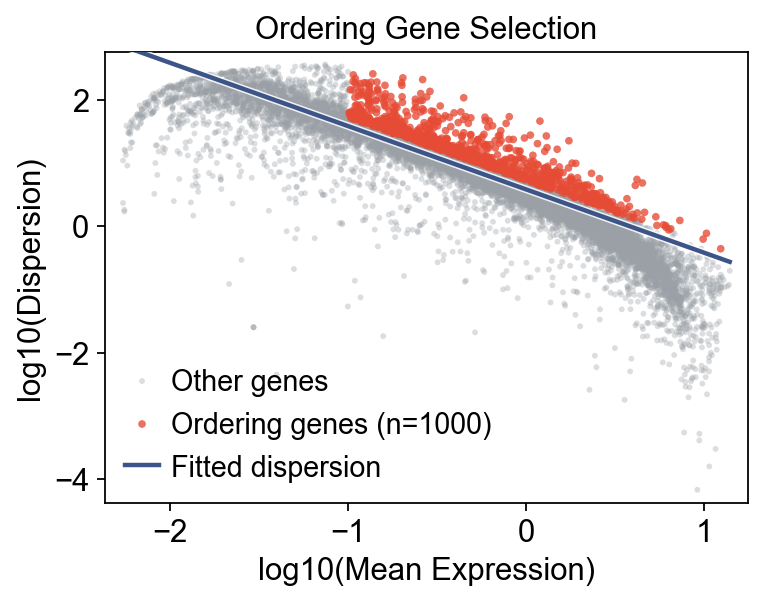

In [6]:
mono = Monocle(adata_wt)
mono.preprocess()
mono.select_ordering_genes(max_genes=1000)
print(f"Ordering genes: {mono.adata.var['use_for_ordering'].sum()}")

mono.plot_ordering_genes(figsize=(5, 4))
plt.show()

## Learn the DDRTree trajectory and order cells

In [7]:
mono.reduce_dimension(max_components=4, verbose=False)
mono.order_cells(root_by_column='subtype', root_by_value='Lsk')
print(mono)

[monocle2_py] Using fast DDRTree (≈3× speed-up, pseudotime correlation with R ≥ 0.99). Pass method='exact' for bitwise R Monocle 2 parity.


Monocle(394 cells × 23955 genes)
  preprocessed: ✓
  ordering genes: 1000
  reduced: DDRTree
  ordered: pseudotime [0.00, 11.99], 12 states


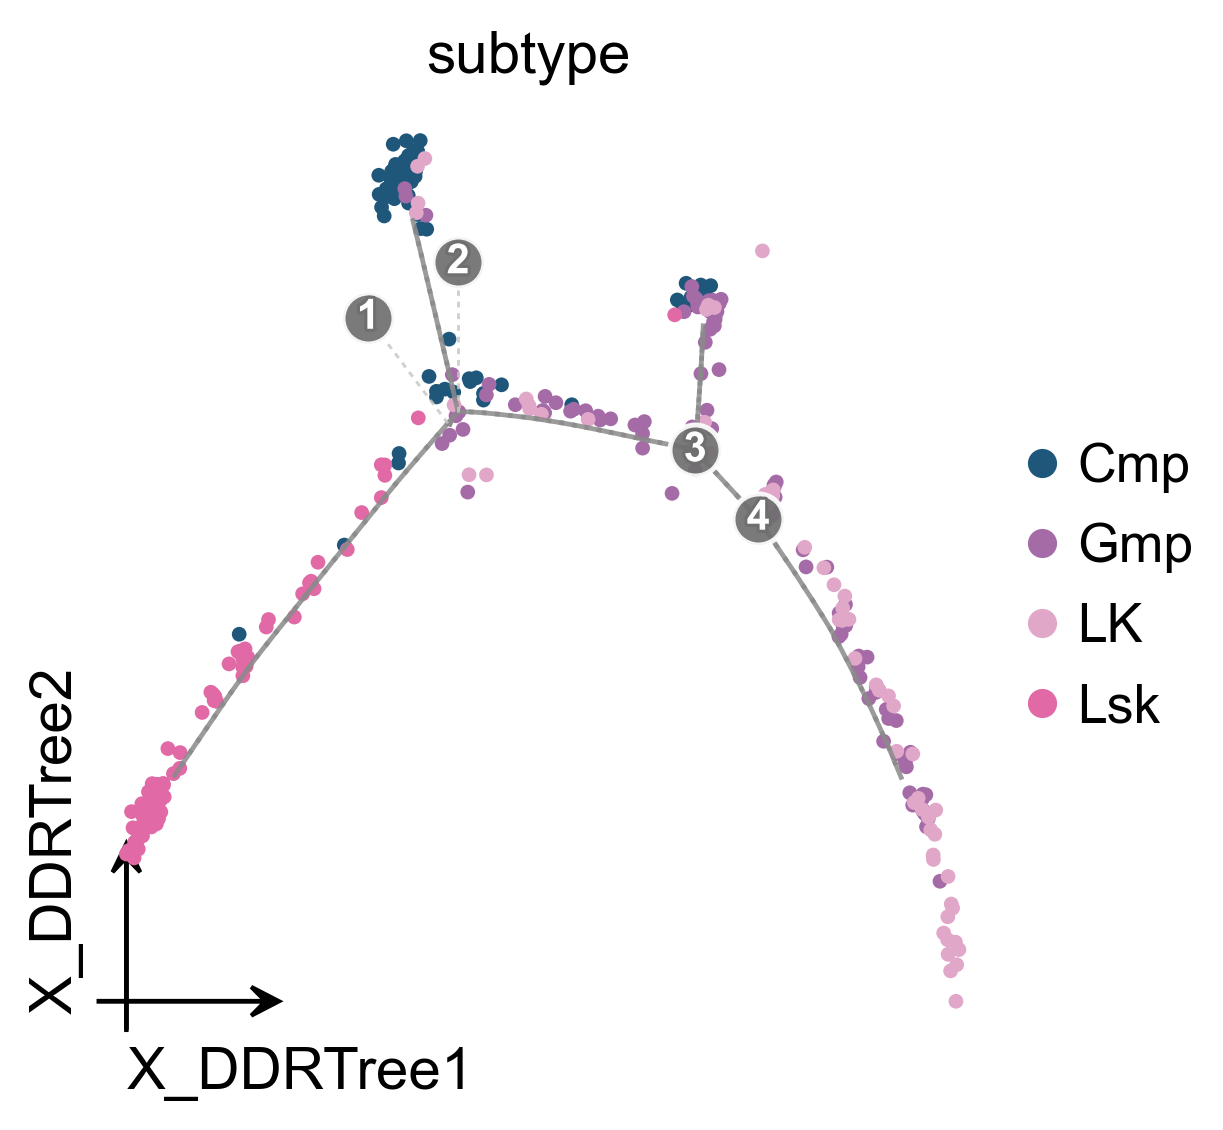

In [8]:
ov.pl.trajectory(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
)
ov.plt.show()

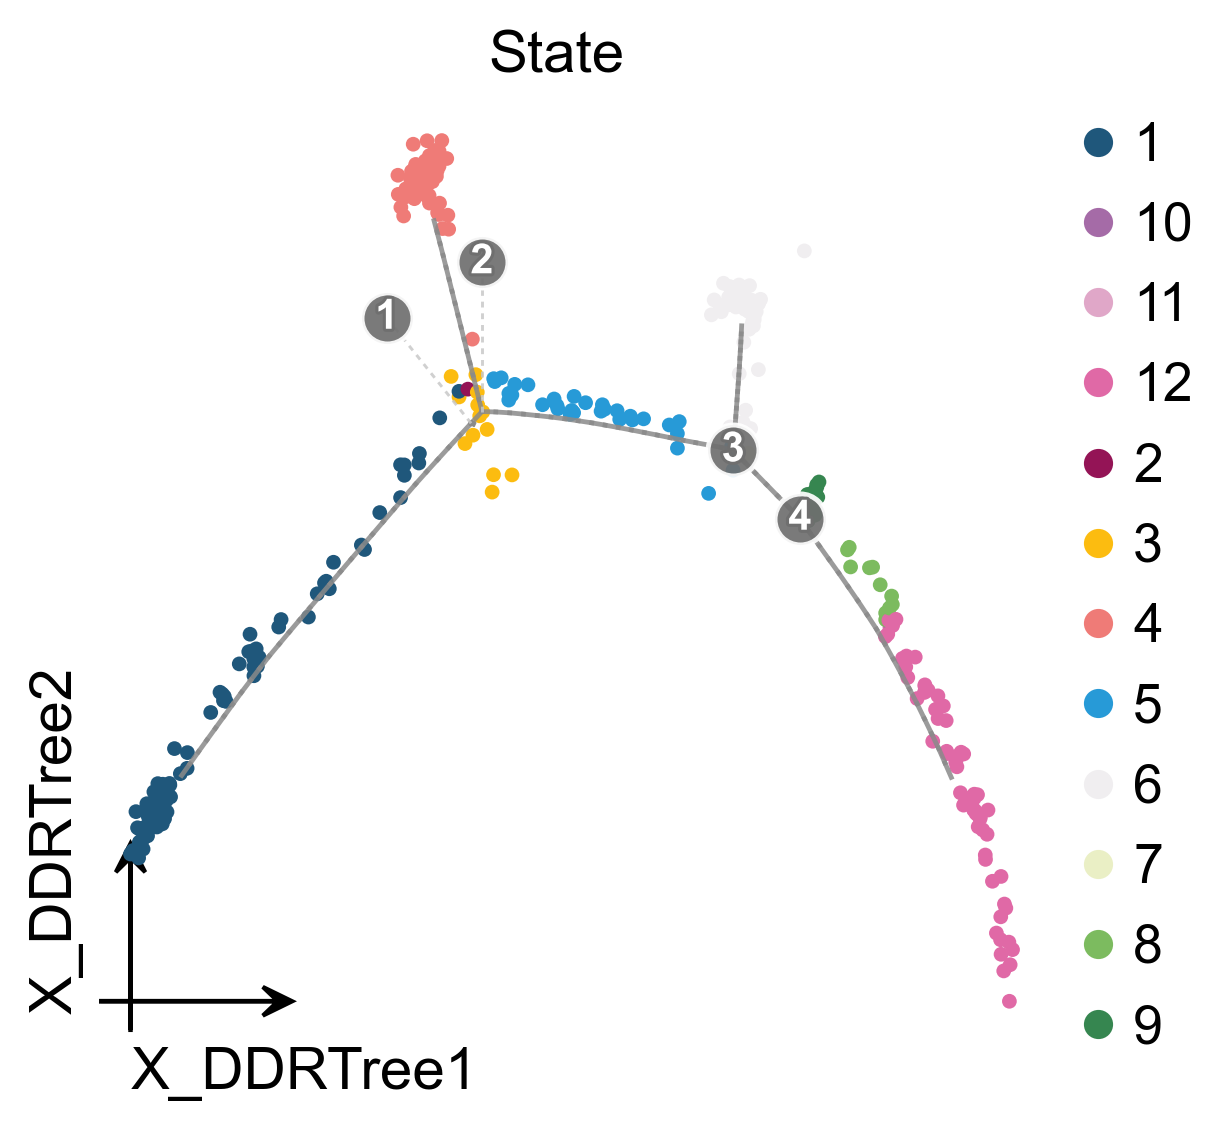

In [9]:
ov.pl.trajectory(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='State',
)
ov.plt.show()

## OV trajectory graph and projection views

The same Monocle result can be shown through the newer `trajectory_graph` and `trajectory_projection` entries, matching the visual API used by the other trajectory tutorials.

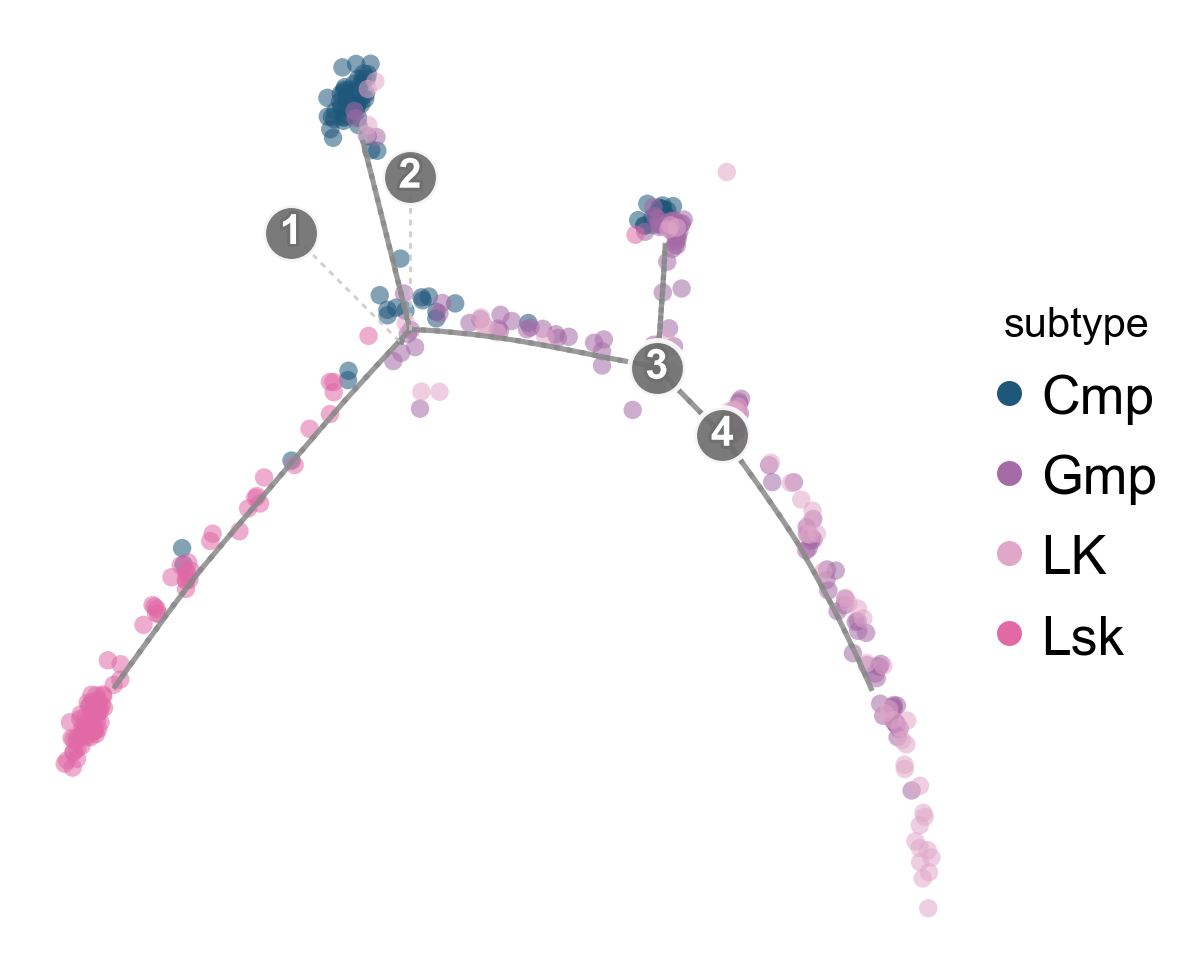

In [10]:
fig, ax = ov.pl.trajectory_graph(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
    figsize=(4, 4),
)
ov.plt.show()

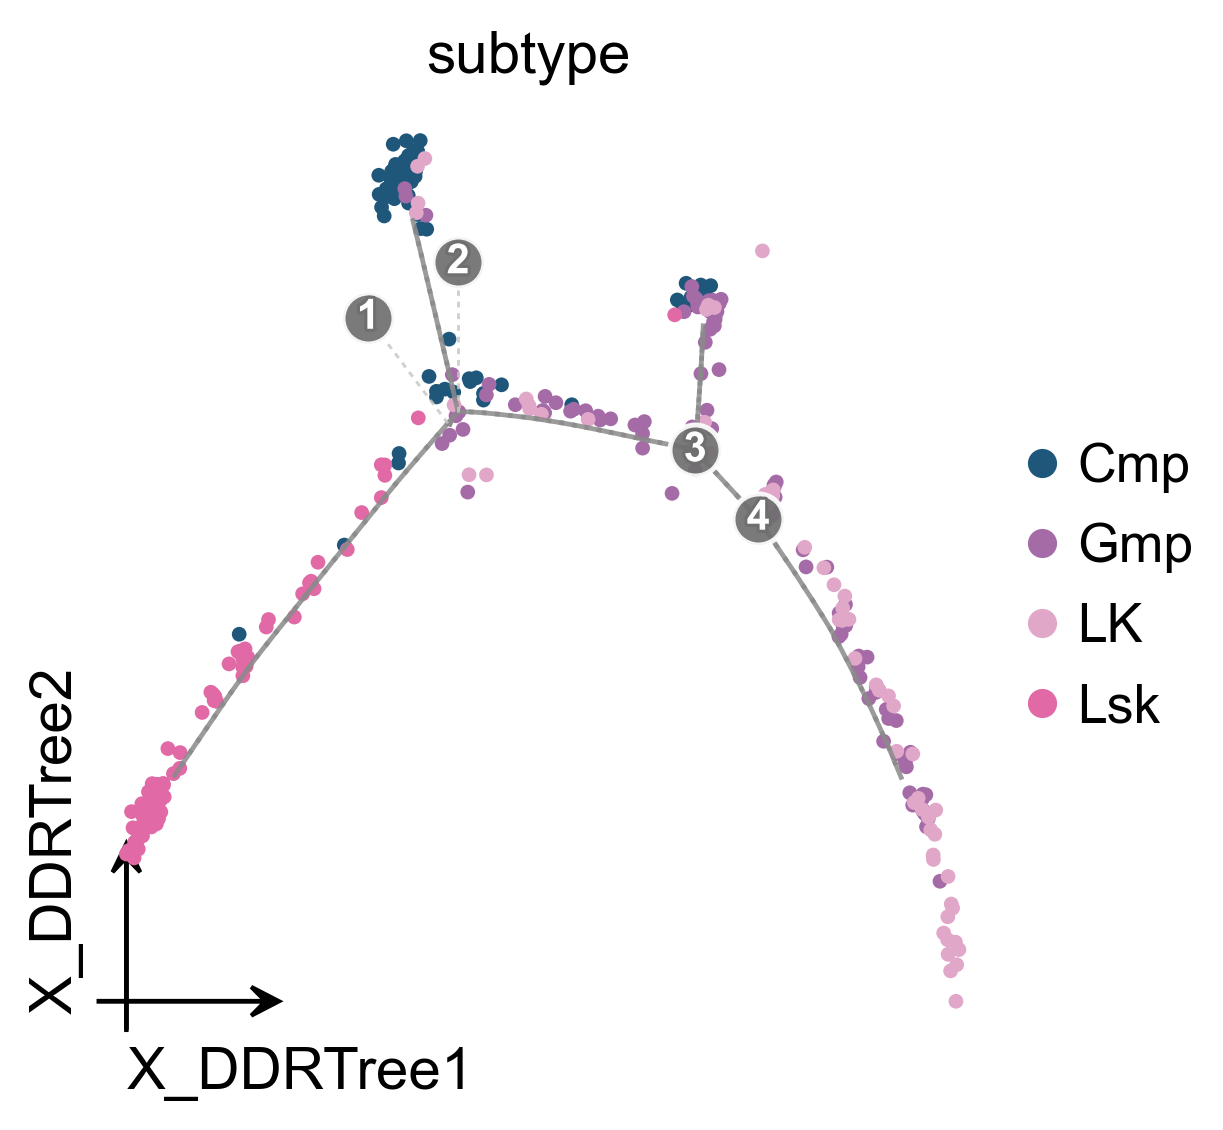

In [11]:
fig, ax = ov.pl.trajectory_projection(
    mono.adata,
    method='monocle',
    basis='X_DDRTree',
    color='subtype',
)
ov.plt.show()

## DDRTree embedding with trajectory overlay

`ov.pl.trajectory_overlay` adds the gray principal graph and branch-point labels to an existing OmicVerse embedding axis, keeping cell colors and legends consistent with `ov.pl.embedding`.

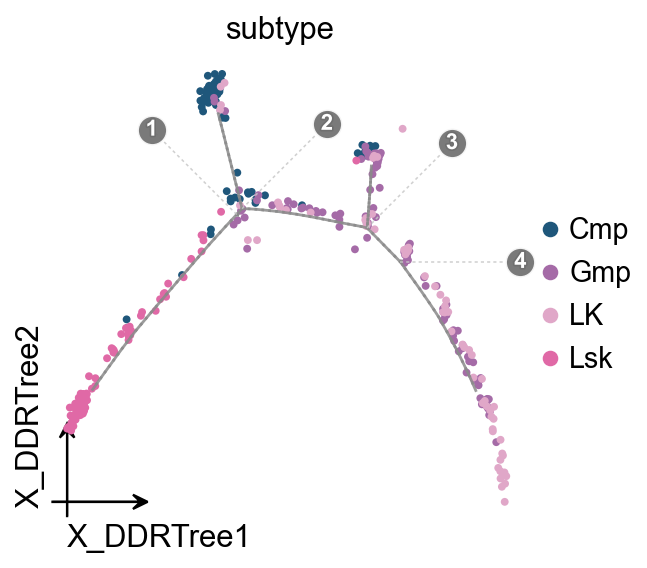

In [12]:
fig, ax = ov.plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    mono.adata,
    basis='X_DDRTree',
    color='subtype',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(mono.adata, ax=ax, method='monocle')
ov.plt.show()

## Complex tree layout

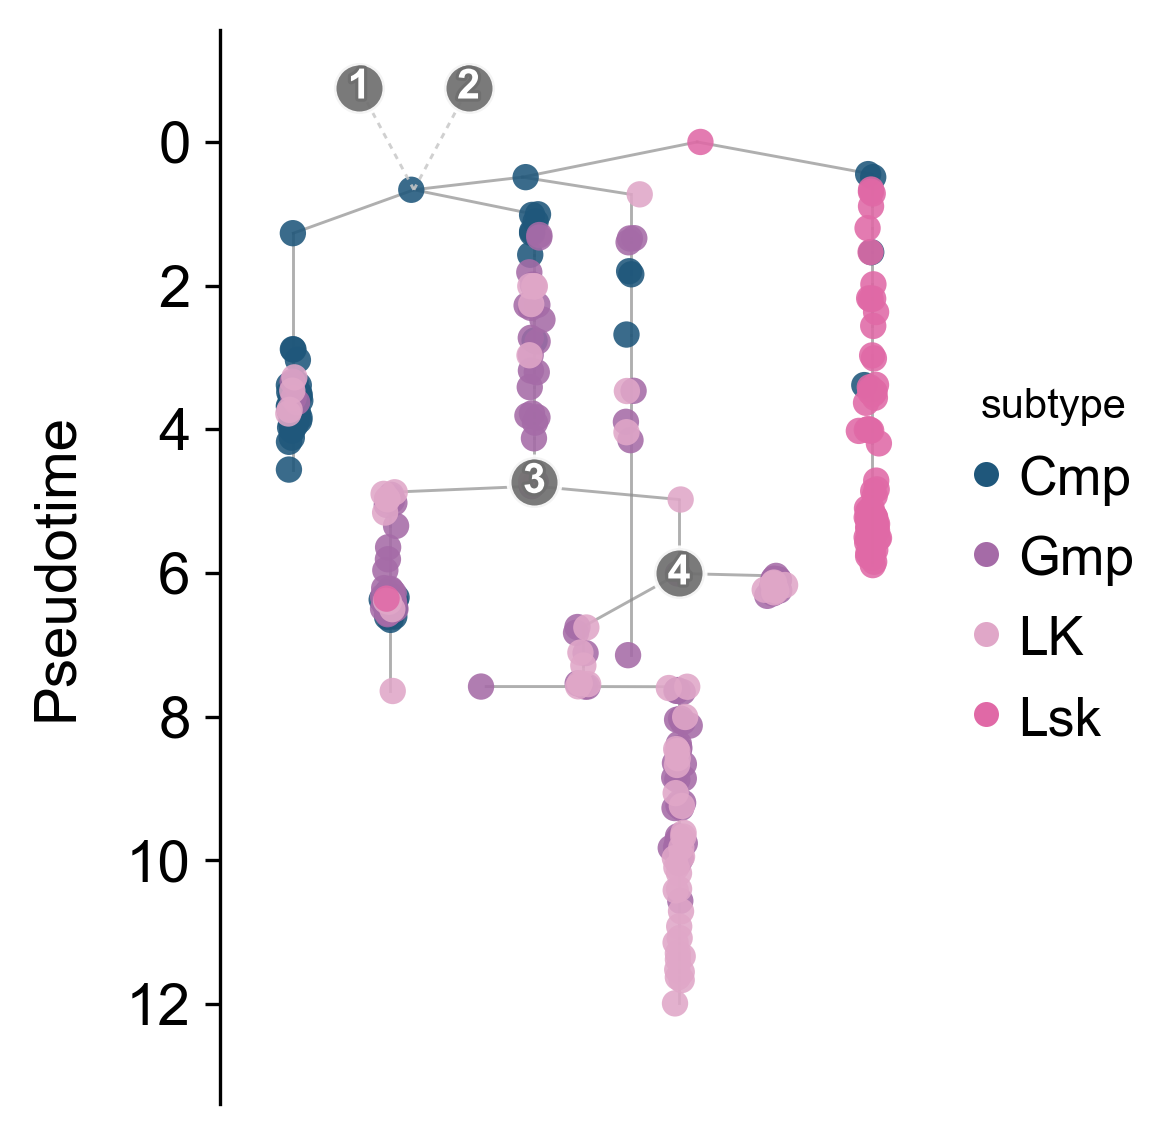

In [13]:
ov.pl.trajectory_tree(
    mono.adata,
    method='monocle',
    color='subtype',
)
ov.plt.show()

## State-versus-subtype correspondence

A simple contingency heatmap helps check whether Monocle states roughly follow the `Lsk -> Cmp/LK -> Gmp` direction.

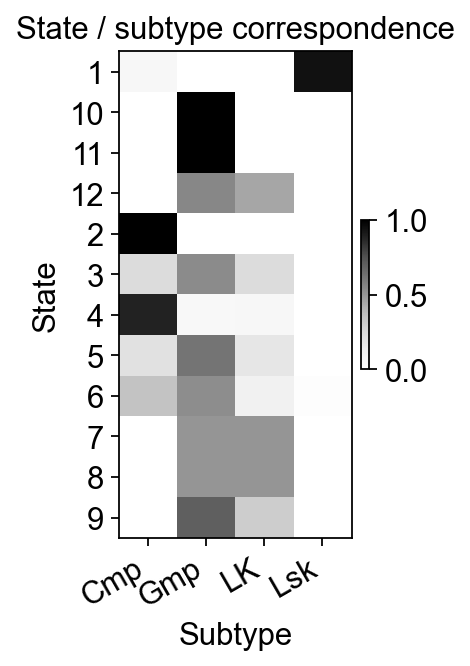

In [14]:
state_subtype = pd.crosstab(mono.adata.obs['State'], mono.adata.obs['subtype'])
state_subtype_norm = state_subtype.div(state_subtype.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(2, 4))
im = ax.imshow(state_subtype_norm.values, aspect='auto', cmap='Greys')
ax.set_xticks(range(state_subtype_norm.shape[1]))
ax.set_xticklabels(state_subtype_norm.columns, rotation=30, ha='right')
ax.set_yticks(range(state_subtype_norm.shape[0]))
ax.set_yticklabels(state_subtype_norm.index)
ax.set_xlabel('Subtype')
ax.set_ylabel('State')
ax.set_title('State / subtype correspondence')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.show()

## Branch-aware pseudotime stream plot

`ov.pl.branch_streamplot` only needs pseudotime and cell-state labels, so it can be used with this trajectory inference method as well. Ribbon width shows where each cell type is enriched along pseudotime, while the branch centerlines make downstream fate separation easier to see.

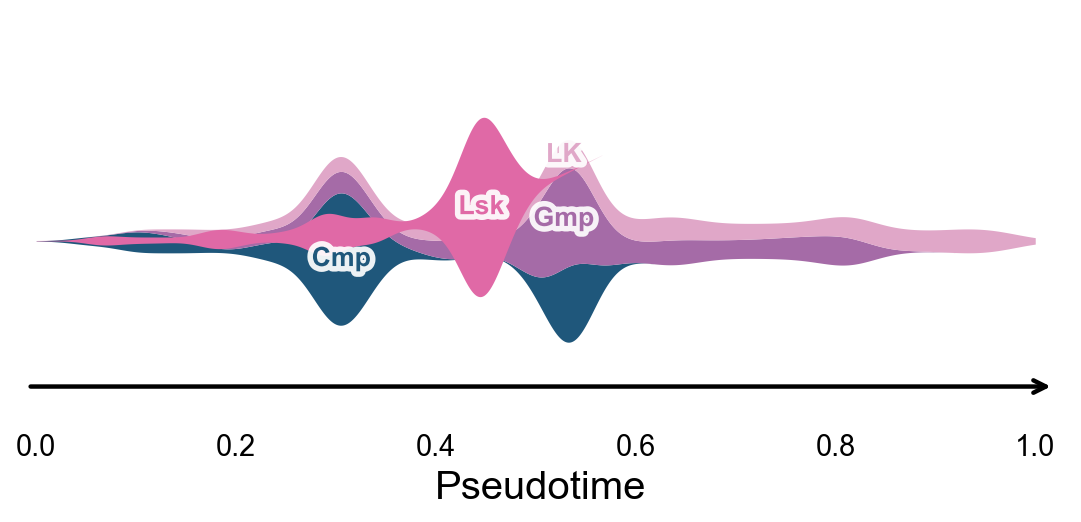

In [15]:
fig, ax = ov.pl.branch_streamplot(
    mono.adata,
    group_key='subtype',
    pseudotime_key='Pseudotime',
    show=False,
)
plt.show()

## Embedding stream plot

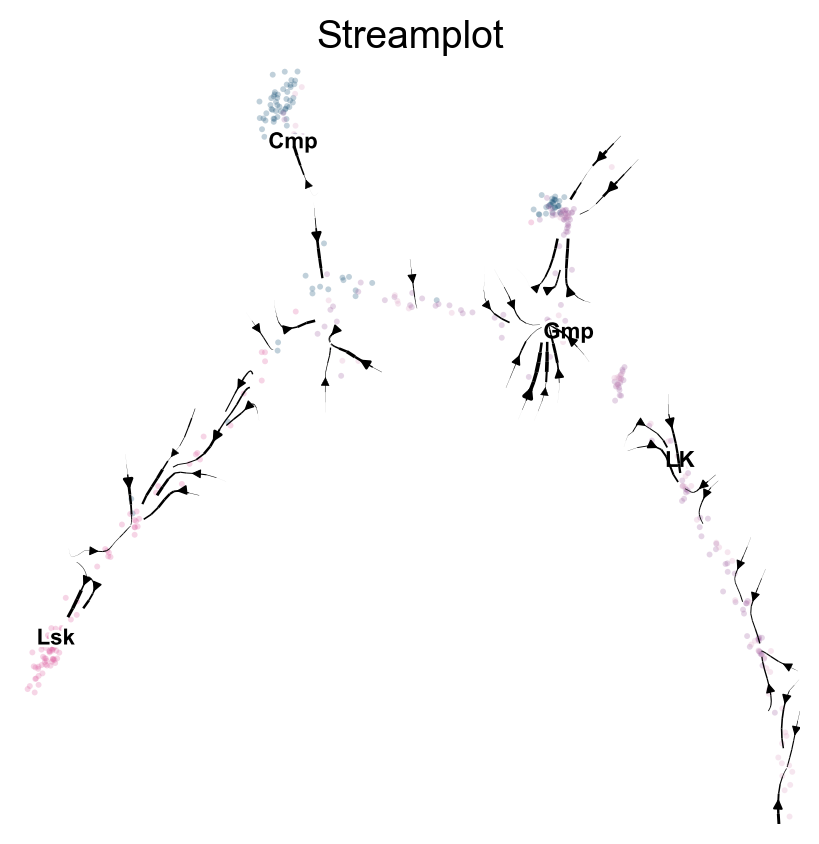

In [16]:
fig, ax = ov.pl.plot_stream(
    mono.adata,
    method="pseudotime",
    figsize=(5, 5),
    dpi=100,
    basis="X_DDRTree",
    pseudotime_key="Pseudotime",
    color="subtype",
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    frameon=False,
    title="Streamplot",
)

## Genes changing along pseudotime


🔍 Dynamic heatmap:
   Candidate features: 40
   Pseudotime: Pseudotime
   Cell annotation: State
   use_fitted=True | cell_bins=200 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 40 features × 122 columns


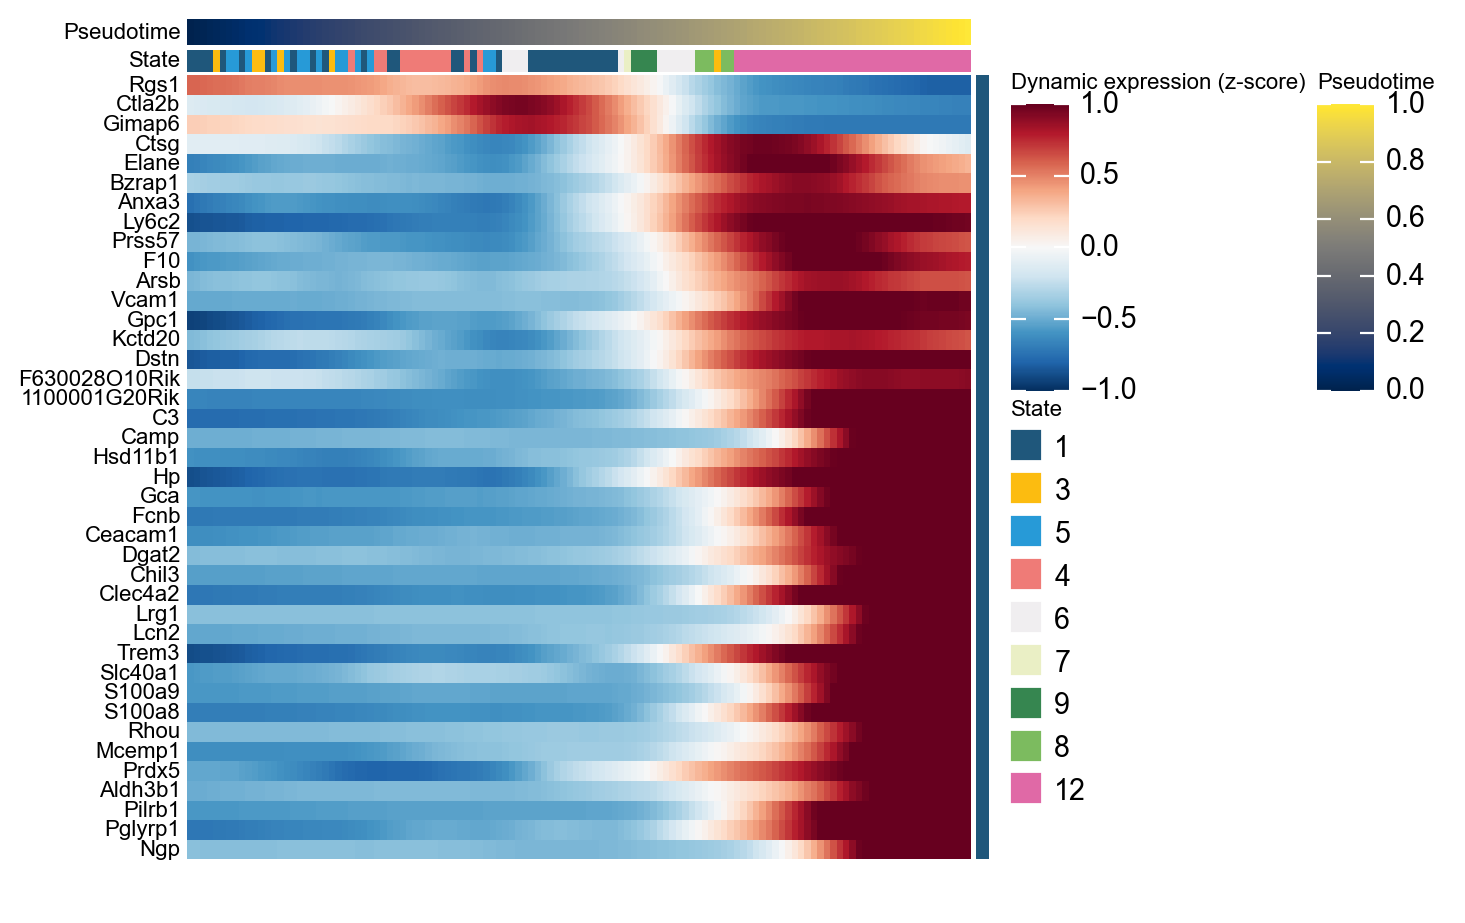

In [17]:
ordering_genes = mono.adata.var_names[mono.adata.var['use_for_ordering']].tolist()
mono_ord = Monocle(mono.adata[:, ordering_genes].copy())

de = mono_ord.differential_gene_test(cores=-1)
sig = de[(de['qval'] < 0.01) & (de['status'] == 'OK')]

top40 = sig.sort_values('pval').head(40).index.tolist()

g = ov.pl.dynamic_heatmap(
    mono.adata,
    pseudotime='Pseudotime',
    var_names=top40,
    cell_annotation='State',
    use_cell_columns=False,
    use_fitted=True,
    cell_bins=200,
    figsize=(7, 7),
    show_row_names=True,
    standard_scale='var',
    cmap='RdBu_r',
    order_by='peak',
    show=False,
)

## Marker genes along pseudotime

Classic hematopoietic markers provide a direct biological sanity check: if the current pseudotime is reasonable, early progenitor markers and later branch markers should appear in an interpretable order.

### Single-line global trends


🔍 Dynamic feature analysis:
   Views: 1 | Features: 6
   Pseudotime: Pseudotime
   Stored raw obs keys: ['State']
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 6/6
   ✓ Fitted rows: 1200
   ✓ Raw observations stored: 2364

🔍 Dynamic trend plotting:
   Features: 6 | Groups: 1
   compare_features=False | compare_groups=False


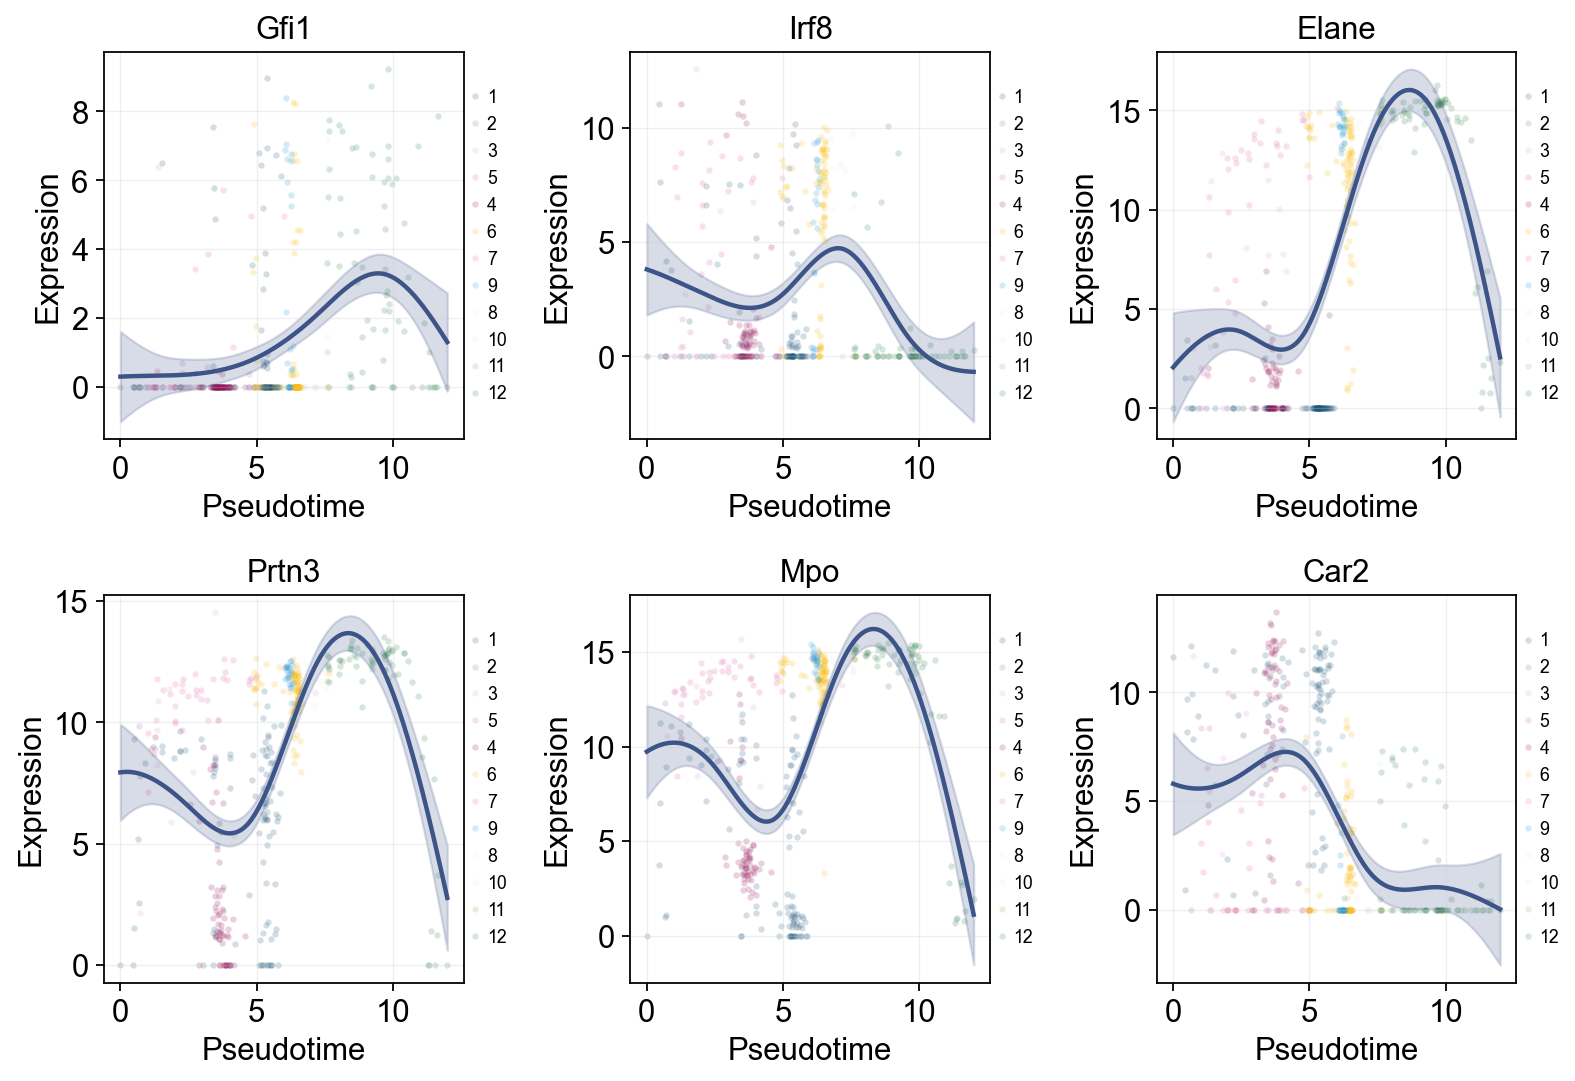

✅ Dynamic trend plotting completed!


In [18]:
import pandas as pd

marker_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Prtn3', 'Mpo', 'Car2'] if g in mono.adata.var_names]

res = ov.single.dynamic_features(
    mono.adata,
    genes=marker_genes,
    pseudotime='Pseudotime',
    store_raw=True,
    raw_obs_keys=['State'],
)

ov.pl.dynamic_trends(
    res,
    genes=marker_genes,
    add_point=True,
    point_color_by='State',
    figsize=(4, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

## Marker dynamics with `dynamic_features` and `dynamic_trends`

`ov.single.dynamic_features` fits GAM trends along Monocle pseudotime. We first draw global marker trends colored by subtype, then fit the two major downstream branches separately for a branch-aware comparison.

In [19]:
marker_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Prtn3', 'Mpo', 'Car2'] if g in mono.adata.var_names]

olsson_global_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=marker_genes,
    pseudotime='Pseudotime',
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['subtype', 'State'],
)

trend_genes = [g for g in ['Gfi1', 'Irf8', 'Elane', 'Car2'] if g in marker_genes]


🔍 Dynamic feature analysis:
   Views: 1 | Features: 6
   Pseudotime: Pseudotime
   Stored raw obs keys: ['subtype', 'State']
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 6/6
   ✓ Fitted rows: 1200
   ✓ Raw observations stored: 2364



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


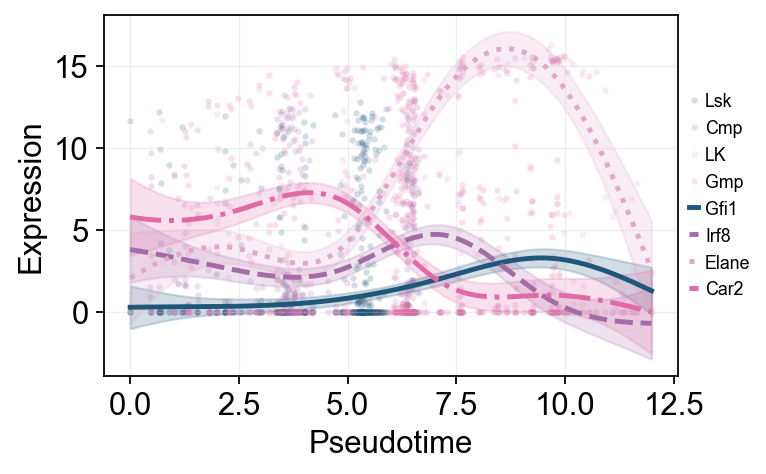

✅ Dynamic trend plotting completed!


In [20]:
ov.pl.dynamic_trends(
    olsson_global_dyn,
    genes=trend_genes,
    compare_features=True,
    add_point=True,
    point_color_by='subtype',
    line_style_by='features',
    figsize=(6, 3.2),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [21]:
branch_subtypes = ['Gmp', 'LK']
branch_split_mask = mono.adata.obs['subtype'].astype(str).isin(['Cmp'])

olsson_branch_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=trend_genes,
    pseudotime='Pseudotime',
    groupby='subtype',
    groups=branch_subtypes,
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
branch_split_time = float(np.nanmedian(mono.adata.obs.loc[branch_split_mask, 'Pseudotime'])) if branch_split_mask.any() else float(np.nanmedian(mono.adata.obs['Pseudotime']))


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: Pseudotime
   Grouping: subtype
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 808



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


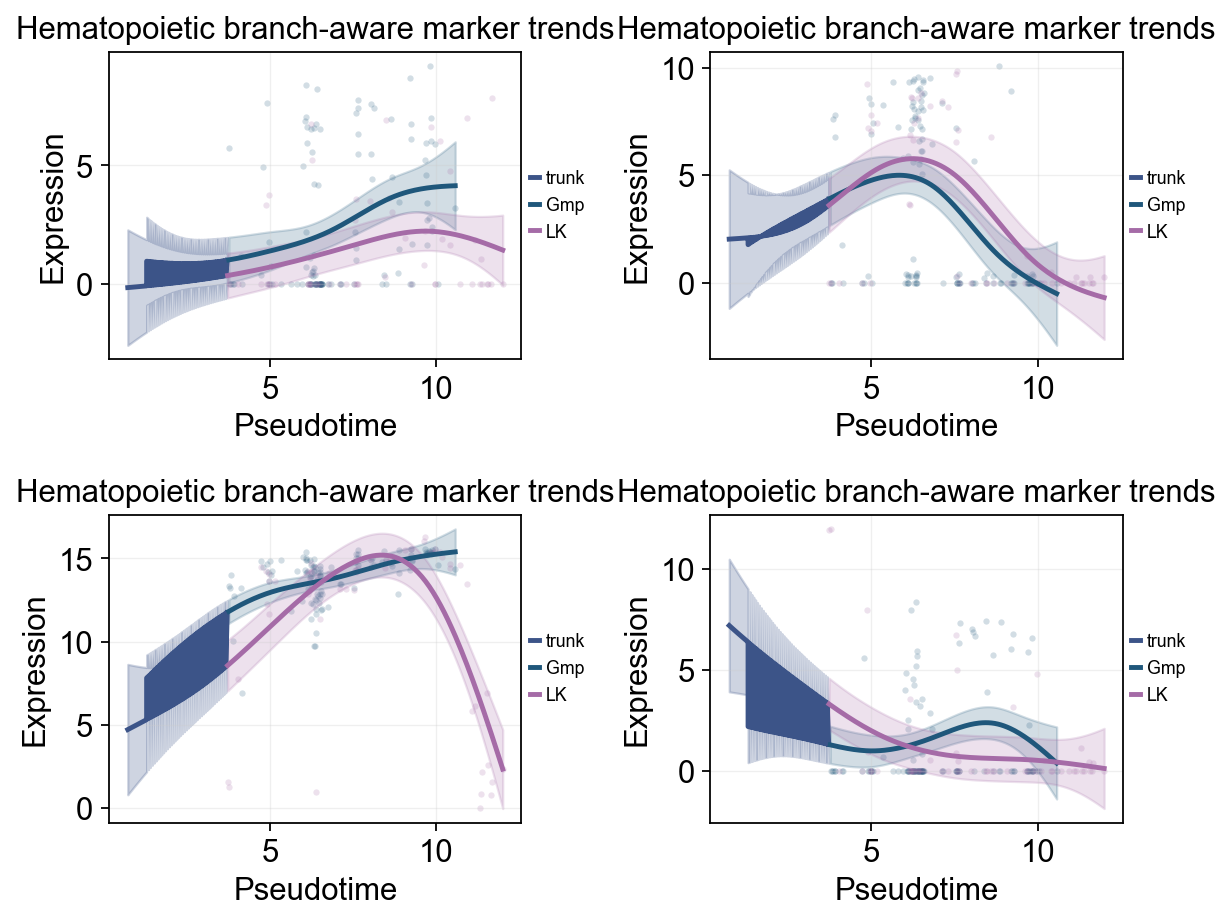

✅ Dynamic trend plotting completed!


In [22]:
ov.pl.dynamic_trends(
    olsson_branch_dyn,
    genes=trend_genes,
    compare_groups=True,
    split_time=branch_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.6, 3),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Hematopoietic branch-aware marker trends',
)
plt.show()

## Summarize hematopoietic programs with `dynamic_heatmap`


🔍 Dynamic heatmap:
   Candidate features: 6
   Pseudotime: Pseudotime
   Cell annotation: subtype
   use_fitted=True | cell_bins=140 | cmap=RdBu_r

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 6 features × 97 columns


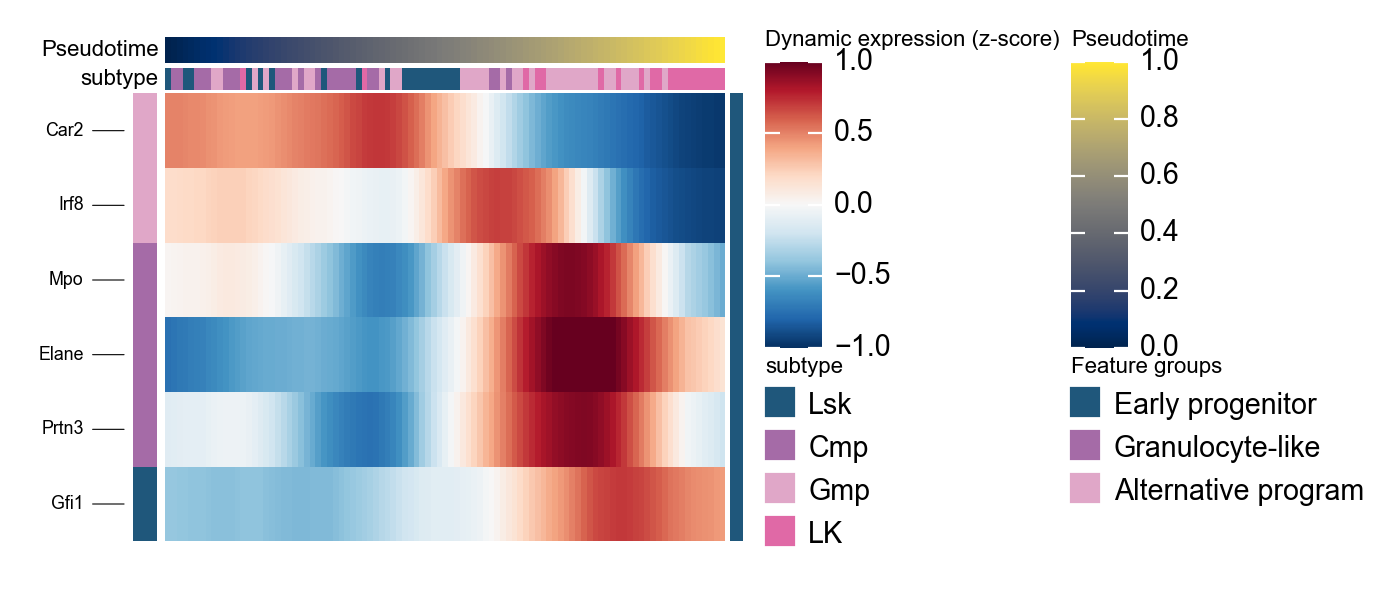

In [23]:
olsson_marker = {
    'Early progenitor': [g for g in ['Gfi1'] if g in mono.adata.var_names],
    'Granulocyte-like': [g for g in ['Elane', 'Prtn3', 'Mpo'] if g in mono.adata.var_names],
    'Alternative program': [g for g in ['Irf8', 'Car2'] if g in mono.adata.var_names],
}
olsson_marker = {k: v for k, v in olsson_marker.items() if v}

g = ov.pl.dynamic_heatmap(
    mono.adata,
    var_names=olsson_marker,
    pseudotime='Pseudotime',
    use_raw=False,
    use_cell_columns=False,
    cell_annotation='subtype',
    cell_bins=140,
    smooth_window=13,
    fitted_window=25,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)

## Branch-dependent genes with BEAM

BEAM ranks genes whose expression changes after the main branch point. Here we use the top significant genes directly in `dynamic_trends` to compare downstream subtype programs.


Significant BEAM genes: 141/1000


         pval  qval
uid                
Gm6289    0.0   0.0
Gm20753   0.0   0.0
Gm20594   0.0   0.0
Gm20172   0.0   0.0
Gm15880   0.0   0.0
Satb2     0.0   0.0
Gm10408   0.0   0.0
Gcm1      0.0   0.0
Gal3st3   0.0   0.0
Rn45s     0.0   0.0


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: Pseudotime
   Grouping: subtype
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 7/8
   ✓ Fitted rows: 1400
   ✓ Raw observations stored: 742

🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


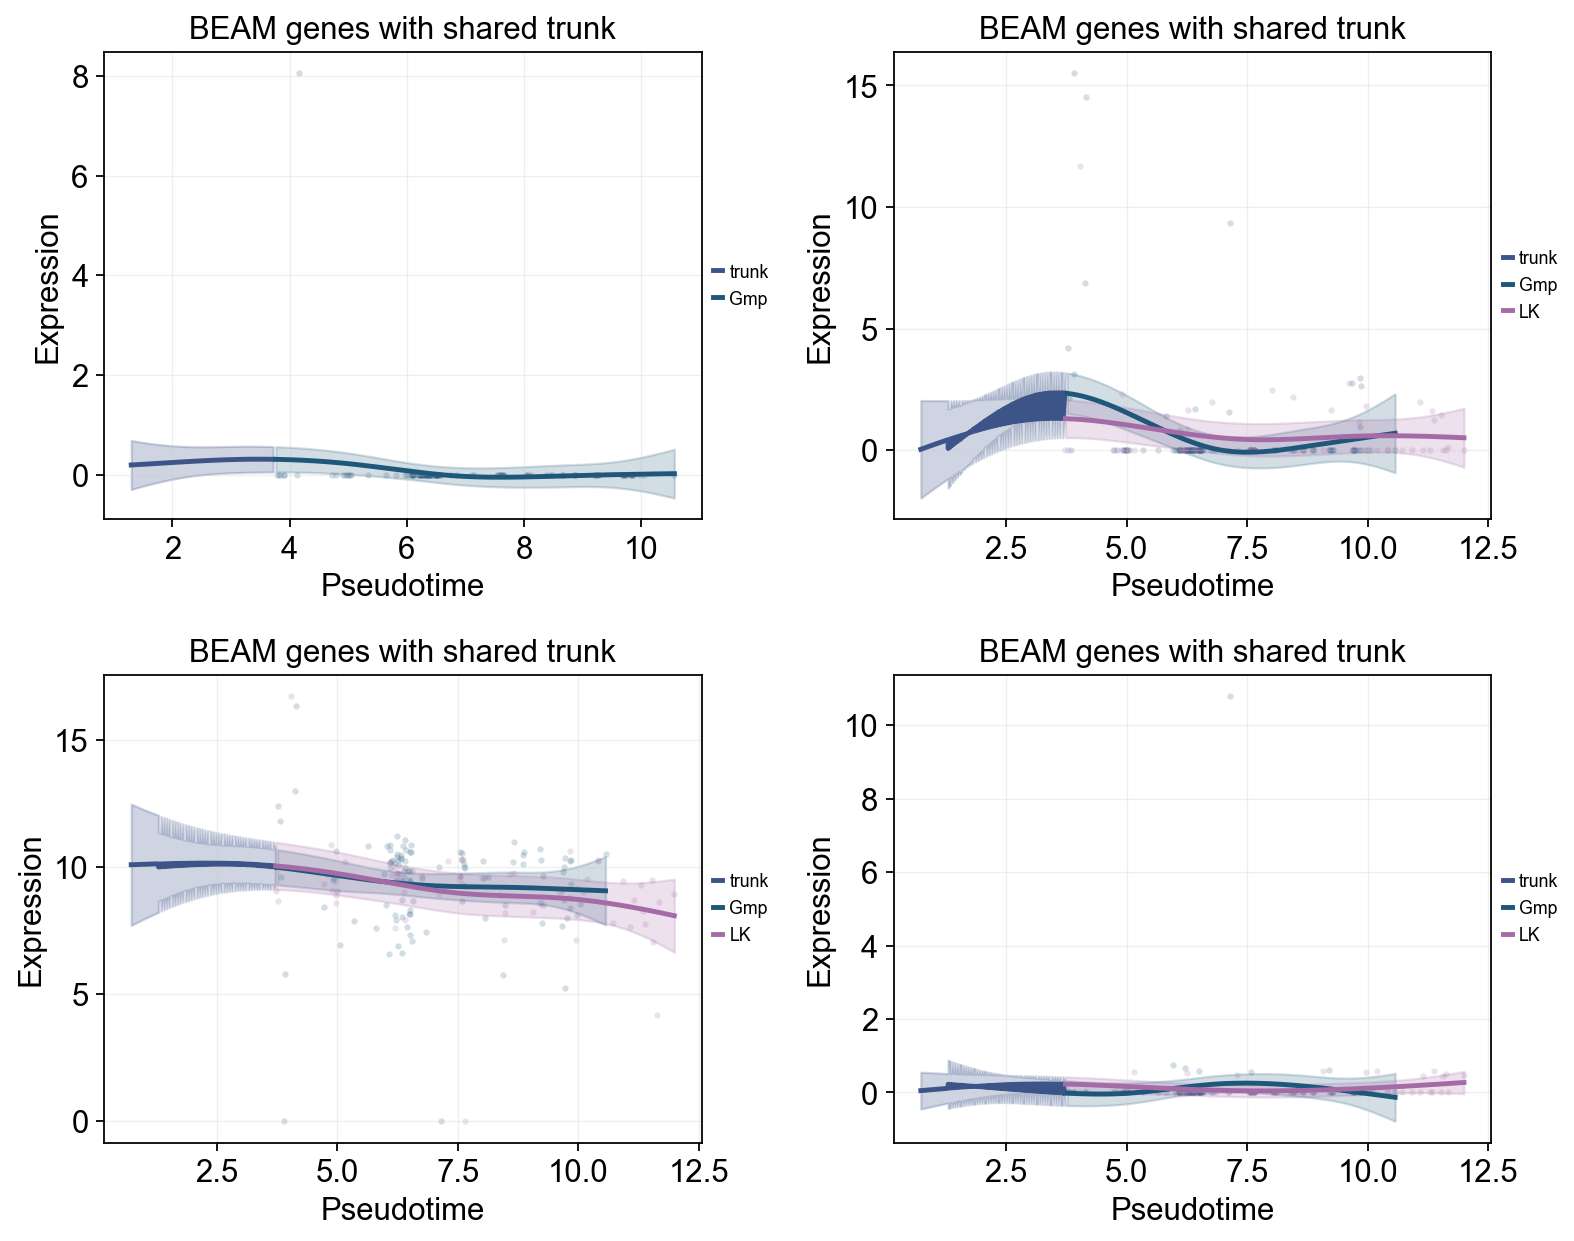

✅ Dynamic trend plotting completed!


In [24]:
beam = mono_ord.BEAM(branch_point=1, cores=-1)
sig_beam = beam[beam['qval'] < 0.01].sort_values('qval')
print(f'Significant BEAM genes: {len(sig_beam)}/{len(beam)}')
display(sig_beam.head(10)[['pval', 'qval']])

top_branch_genes = sig_beam.head(4).index.tolist()
beam_branch_subtypes = ['Gmp', 'LK']

beam_dyn = ov.single.dynamic_features(
    mono.adata,
    genes=top_branch_genes,
    pseudotime='Pseudotime',
    groupby='subtype',
    groups=beam_branch_subtypes,
    use_raw=False,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
beam_split_mask = mono.adata.obs['subtype'].astype(str).isin(['Cmp'])
beam_split_time = float(np.nanmedian(mono.adata.obs.loc[beam_split_mask, 'Pseudotime'])) if beam_split_mask.any() else float(np.nanmedian(mono.adata.obs['Pseudotime']))

ov.pl.dynamic_trends(
    beam_dyn,
    genes=top_branch_genes,
    compare_groups=True,
    split_time=beam_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(6, 4),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='BEAM genes with shared trunk',
)
plt.show()